# Set Up

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.chdir("/content/drive/MyDrive/Bayes ML Project")
!pwd

/content/drive/MyDrive/Bayes ML Project


In [4]:
df = pd.read_csv("master_monthly_dataset.csv")

In [5]:
# Additional Industrial Production Vars
df["Industrial_Production_MoM"] = (
    df["Industrial_Production"].pct_change(1) * 100
)

df["Industrial_Production_QoQ"] = (
    df["Industrial_Production"].pct_change(3) * 100
)

In [6]:
# Additional Housing Starts Vars
df["Housing_Starts_MoM"] = (
    df["Housing_Starts"].pct_change(1) * 100
)

df["Housing_Starts_QoQ"] = (
    df["Housing_Starts"].pct_change(3) * 100
)

In [7]:
# Additional UE Vars
df["Unemployment_Rate_YoY_Change"] = (
    df["Unemployment_Rate"].diff(12)
)

df["Unemployment_Rate_QoQ_Change"] = (
    df["Unemployment_Rate"].diff(3)
)

In [8]:
# 3-month moving average of Housing Starts
df["Housing_Starts_3MA"] = (
    df["Housing_Starts"]
    .rolling(window=3)
    .mean()
)

# 1-month change in the 3-month moving average
df["Housing_Starts_3MA_1M_Change"] = (
    df["Housing_Starts_3MA"]
    .pct_change(1) * 100
)

# 3-month change in the 3-month moving average
df["Housing_Starts_3MA_3M_Change"] = (
    df["Housing_Starts_3MA"]
    .pct_change(3) * 100
)

# 12-month change in the 3-month moving average
df["Housing_Starts_3MA_12M_Change"] = (
    df["Housing_Starts_3MA"]
    .pct_change(12) * 100
)

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

In [10]:
# Drop Rows with NaN due to change metrics
df.dropna(inplace=True)

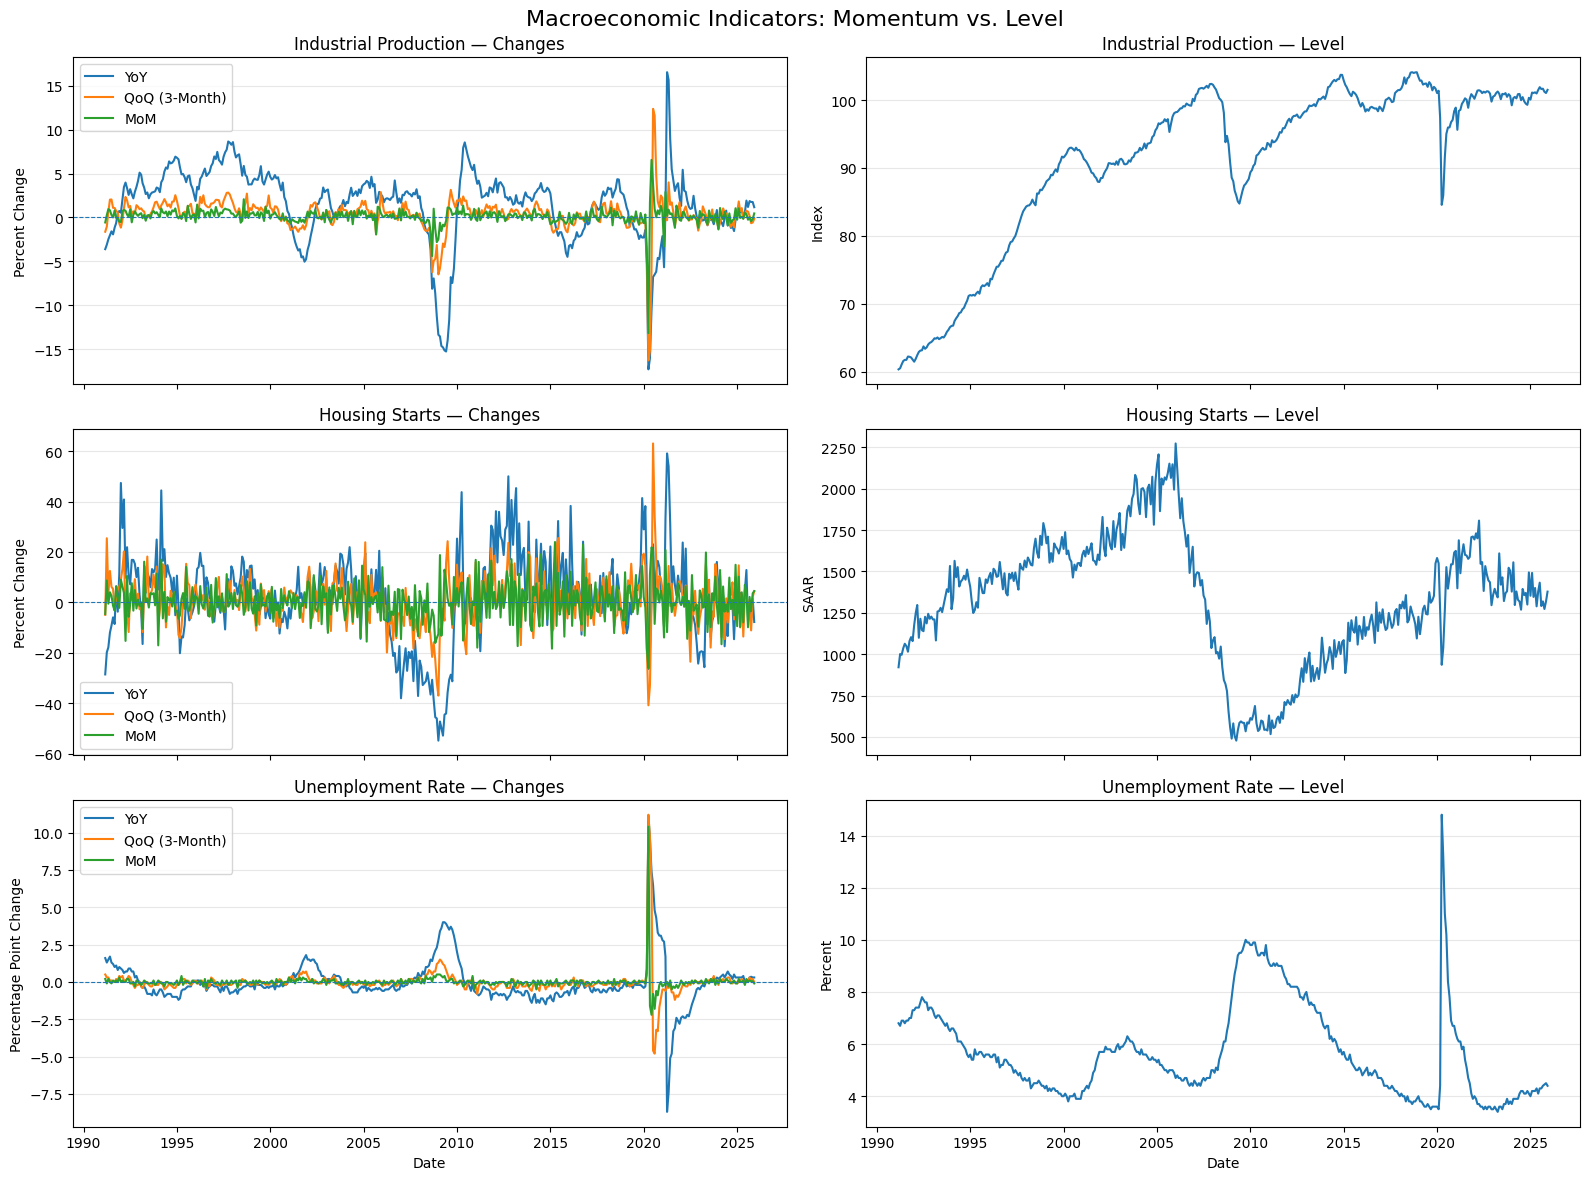

In [11]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 12),
    sharex=True
)

# --------------------------------------------------
# 1. Industrial Production
# --------------------------------------------------

axes[0, 0].plot(
    df["Date"],
    df["Industrial_Production_YoY"],
    label="YoY"
)

axes[0, 0].plot(
    df["Date"],
    df["Industrial_Production_QoQ"],
    label="QoQ (3-Month)"
)

axes[0, 0].plot(
    df["Date"],
    df["Industrial_Production_MoM"],
    label="MoM"
)

axes[0, 0].axhline(0, linewidth=0.8, linestyle="--")
axes[0, 0].set_title("Industrial Production — Changes")
axes[0, 0].set_ylabel("Percent Change")
axes[0, 0].legend()


axes[0, 1].plot(
    df["Date"],
    df["Industrial_Production"]
)

axes[0, 1].set_title("Industrial Production — Level")
axes[0, 1].set_ylabel("Index")


# --------------------------------------------------
# 2. Housing Starts
# --------------------------------------------------

axes[1, 0].plot(
    df["Date"],
    df["Housing_Starts_YoY"],
    label="YoY"
)

axes[1, 0].plot(
    df["Date"],
    df["Housing_Starts_QoQ"],
    label="QoQ (3-Month)"
)

axes[1, 0].plot(
    df["Date"],
    df["Housing_Starts_MoM"],
    label="MoM"
)

axes[1, 0].axhline(0, linewidth=0.8, linestyle="--")
axes[1, 0].set_title("Housing Starts — Changes")
axes[1, 0].set_ylabel("Percent Change")
axes[1, 0].legend()


axes[1, 1].plot(
    df["Date"],
    df["Housing_Starts"]
)

axes[1, 1].set_title("Housing Starts — Level")
axes[1, 1].set_ylabel("SAAR")


# --------------------------------------------------
# 3. Unemployment Rate
# --------------------------------------------------

axes[2, 0].plot(
    df["Date"],
    df["Unemployment_Rate_YoY_Change"],
    label="YoY"
)

axes[2, 0].plot(
    df["Date"],
    df["Unemployment_Rate_QoQ_Change"],
    label="QoQ (3-Month)"
)

axes[2, 0].plot(
    df["Date"],
    df["Unemployment_Rate_MoM_Change"],
    label="MoM"
)

axes[2, 0].axhline(0, linewidth=0.8, linestyle="--")
axes[2, 0].set_title("Unemployment Rate — Changes")
axes[2, 0].set_ylabel("Percentage Point Change")
axes[2, 0].set_xlabel("Date")
axes[2, 0].legend()


axes[2, 1].plot(
    df["Date"],
    df["Unemployment_Rate"]
)

axes[2, 1].set_title("Unemployment Rate — Level")
axes[2, 1].set_ylabel("Percent")
axes[2, 1].set_xlabel("Date")


# --------------------------------------------------
# Formatting
# --------------------------------------------------

for ax in axes.flat:

    # Horizontal gridlines only
    ax.grid(
        axis="y",
        alpha=0.3
    )

    # Show years only on x-axis
    ax.xaxis.set_major_locator(
        mdates.YearLocator(5)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y")
    )

fig.suptitle(
    "Macroeconomic Indicators: Momentum vs. Level",
    fontsize=16
)

plt.tight_layout()

plt.show()

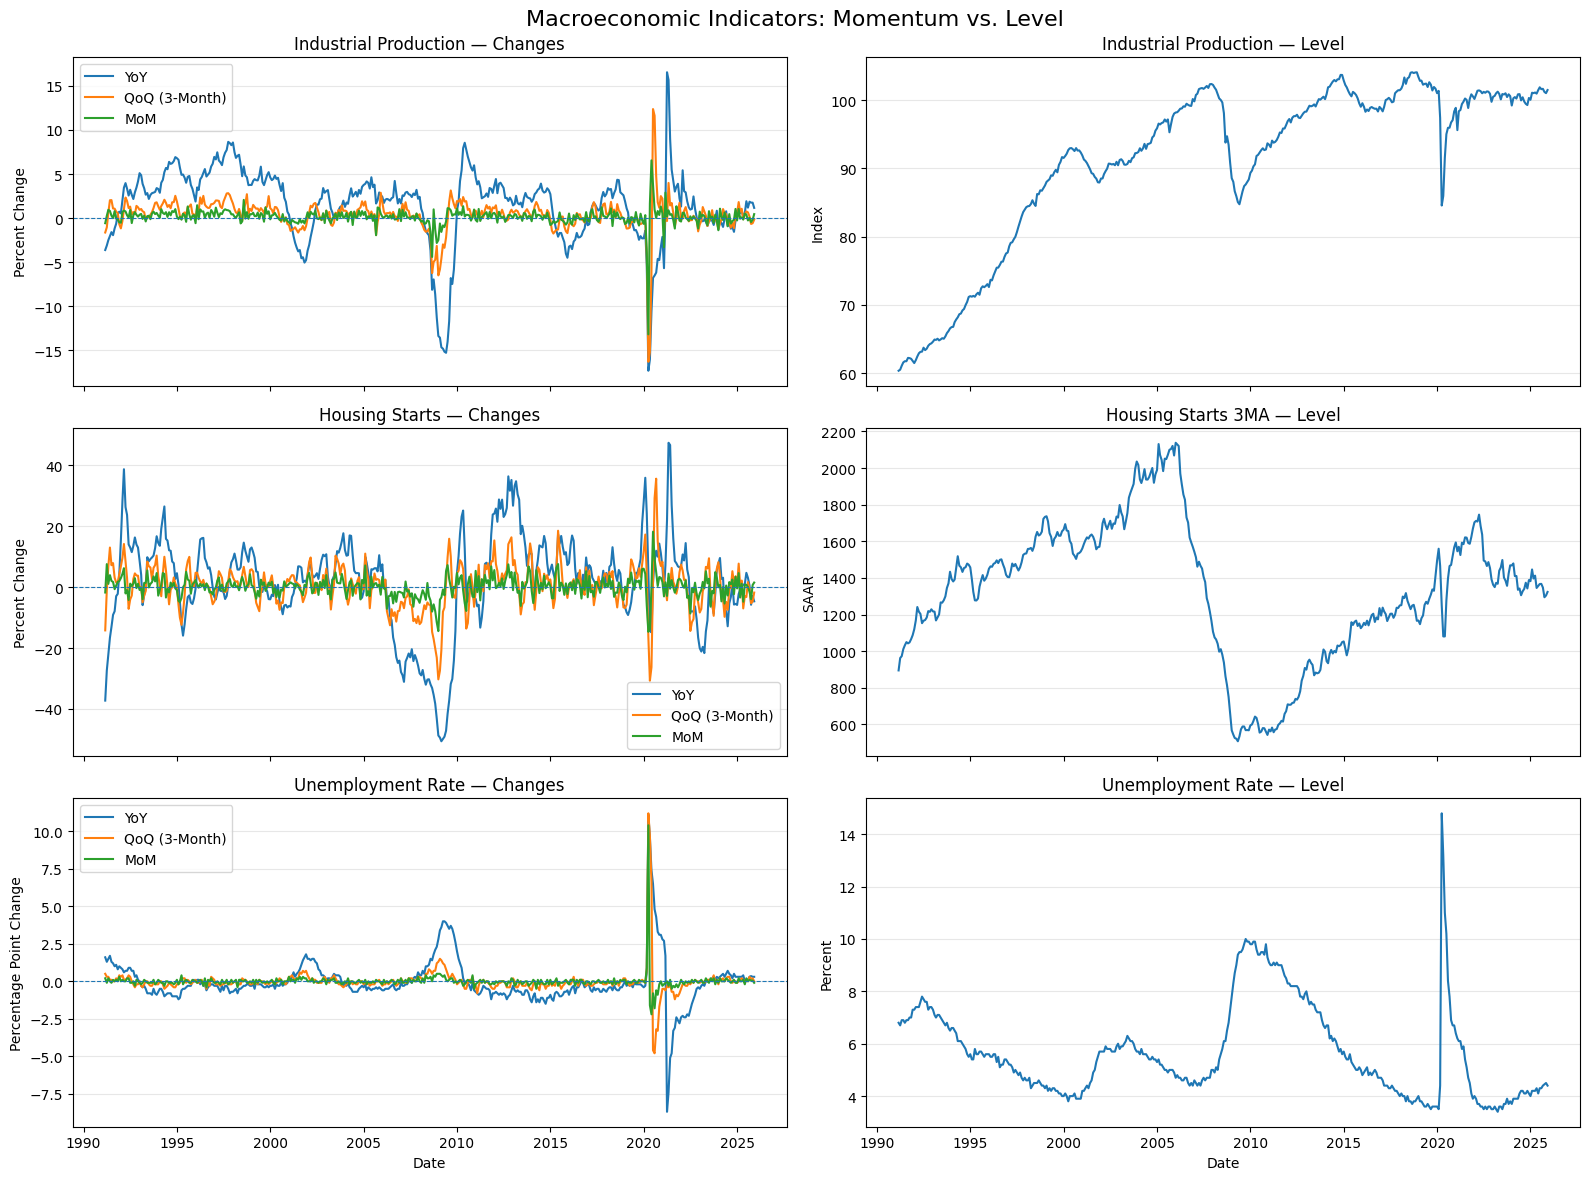

In [12]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 12),
    sharex=True
)

# --------------------------------------------------
# 1. Industrial Production
# --------------------------------------------------

axes[0, 0].plot(
    df["Date"],
    df["Industrial_Production_YoY"],
    label="YoY"
)

axes[0, 0].plot(
    df["Date"],
    df["Industrial_Production_QoQ"],
    label="QoQ (3-Month)"
)

axes[0, 0].plot(
    df["Date"],
    df["Industrial_Production_MoM"],
    label="MoM"
)

axes[0, 0].axhline(0, linewidth=0.8, linestyle="--")
axes[0, 0].set_title("Industrial Production — Changes")
axes[0, 0].set_ylabel("Percent Change")
axes[0, 0].legend()


axes[0, 1].plot(
    df["Date"],
    df["Industrial_Production"]
)

axes[0, 1].set_title("Industrial Production — Level")
axes[0, 1].set_ylabel("Index")


# --------------------------------------------------
# 2. Housing Starts
# --------------------------------------------------

axes[1, 0].plot(
    df["Date"],
    df["Housing_Starts_3MA_12M_Change"],
    label="YoY"
)

axes[1, 0].plot(
    df["Date"],
    df["Housing_Starts_3MA_3M_Change"],
    label="QoQ (3-Month)"
)

axes[1, 0].plot(
    df["Date"],
    df["Housing_Starts_3MA_1M_Change"],
    label="MoM"
)

axes[1, 0].axhline(0, linewidth=0.8, linestyle="--")
axes[1, 0].set_title("Housing Starts — Changes")
axes[1, 0].set_ylabel("Percent Change")
axes[1, 0].legend()


axes[1, 1].plot(
    df["Date"],
    df["Housing_Starts_3MA"]
)

axes[1, 1].set_title("Housing Starts 3MA — Level")
axes[1, 1].set_ylabel("SAAR")


# --------------------------------------------------
# 3. Unemployment Rate
# --------------------------------------------------

axes[2, 0].plot(
    df["Date"],
    df["Unemployment_Rate_YoY_Change"],
    label="YoY"
)

axes[2, 0].plot(
    df["Date"],
    df["Unemployment_Rate_QoQ_Change"],
    label="QoQ (3-Month)"
)

axes[2, 0].plot(
    df["Date"],
    df["Unemployment_Rate_MoM_Change"],
    label="MoM"
)

axes[2, 0].axhline(0, linewidth=0.8, linestyle="--")
axes[2, 0].set_title("Unemployment Rate — Changes")
axes[2, 0].set_ylabel("Percentage Point Change")
axes[2, 0].set_xlabel("Date")
axes[2, 0].legend()


axes[2, 1].plot(
    df["Date"],
    df["Unemployment_Rate"]
)

axes[2, 1].set_title("Unemployment Rate — Level")
axes[2, 1].set_ylabel("Percent")
axes[2, 1].set_xlabel("Date")


# --------------------------------------------------
# Formatting
# --------------------------------------------------

for ax in axes.flat:

    # Horizontal gridlines only
    ax.grid(
        axis="y",
        alpha=0.3
    )

    # Show years only on x-axis
    ax.xaxis.set_major_locator(
        mdates.YearLocator(5)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y")
    )

fig.suptitle(
    "Macroeconomic Indicators: Momentum vs. Level",
    fontsize=16
)

plt.tight_layout()

fig.savefig(
    "time_series_plots.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [13]:
# Set Date as Index
df.set_index('Date', inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 418 entries, 1991-03-01 to 2025-12-01
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CPI                            418 non-null    float64
 1   Unemployment_Rate              418 non-null    float64
 2   Federal_Funds_Rate             418 non-null    float64
 3   Yield_Curve_Spread_MonthAvg    418 non-null    float64
 4   Yield_Curve_Spread_MonthEnd    418 non-null    float64
 5   Industrial_Production          418 non-null    float64
 6   Housing_Starts                 418 non-null    float64
 7   Nominal_PCE                    418 non-null    float64
 8   VIX_MonthAvg                   418 non-null    float64
 9   VIX_MonthEnd                   418 non-null    float64
 10  Real_PCE                       418 non-null    float64
 11  CPI_YoY                        418 non-null    float64
 12  Industrial_Production_YoY      

# Model

- Yield_Curve_Spread_MonthEnd
- CPI_YoY, Industrial_Production_YoY
- Housing_Starts_YoY, Real_PCE_YoY
- Unemployment_Rate_MoM_Change
- Federal_Funds_Rate_MoM_Change,
- Log_VIX_MonthAvg

The Baum-Welch algorithm is a specialized application of the Expectation-Maximization (EM) algorithm used to train Hidden Markov Models (HMMs). It iteratively updates an HMM's parameters—transition matrices, emission matrices, and initial state distributions—to maximize the likelihood of a set of observed data sequences when hidden states are unobserved

In [15]:
# Discretize Observed Variables
observed_vars = [
    "Yield_Curve_Spread_MonthEnd",
    "CPI_YoY",
    "Industrial_Production_YoY",
    "Industrial_Production_MoM",
    "Housing_Starts_YoY",
    "Housing_Starts_MoM",
    "Real_PCE_YoY",
    "Unemployment_Rate_YoY_Change",
    "Unemployment_Rate_MoM_Change",
    "Log_VIX_MonthAvg"
]

df_discrete = df.copy()
df_discrete = df_discrete[observed_vars]

cutpoints = {}

for col in observed_vars:

    q1 = df[col].quantile(1/3)
    q2 = df[col].quantile(2/3)

    cutpoints[col] = (q1, q2)

    df_discrete[col] = pd.cut(
        df[col],
        bins=[-np.inf, q1, q2, np.inf],
        labels=[0, 1, 2],
        include_lowest=True
    )

In [16]:
df_discrete[observed_vars] = (
    df_discrete[observed_vars]
    .astype(int)
)

X = df_discrete[observed_vars].to_numpy()

print(X.shape)

(418, 10)


- Initial State distribution uses an uninformed even weight
- Transistion probabilties are set a symetric A matrix with high value in the diagonal and all rows/cols summing to 1.
- Each cell in each emission matrix is between 0 and 1 and set so that each row sums to 1, since each state is a row.

In [17]:
# Initialization Function
def initialize_dbn(
    n_variables,
    n_states=3,
    n_categories=3,
    persistence=0.80,
    random_state=None
):

    """
    Initialize HMM / DBN parameters.

    Returns
    -------
    pi : shape (n_states,)
        Initial hidden-state probabilities.

    A : shape (n_states, n_states)
        Transition matrix.

    B : shape (n_variables, n_states, n_categories)
        Emission probabilities.
        B[v, s, k] = P(X_v = k | S = s)
    """

    rng = np.random.default_rng(random_state)

    # Initial state probabilities

    pi = np.ones(n_states) / n_states

    # Transition probabilities

    off_diag = (1 - persistence) / (n_states - 1)

    A = np.full(
        (n_states, n_states),
        off_diag
    )

    np.fill_diagonal(A, persistence)

    # Emission probabilities

    B = np.empty(
        (
            n_variables,
            n_states,
            n_categories
        )
    )

    for v in range(n_variables):
        for s in range(n_states):

            B[v, s] = rng.dirichlet(
                np.ones(n_categories)
            )

    return pi, A, B

In [18]:
# Emission Likelihood Function
def emission_likelihood(X, B):
    """
    Compute P(X_t | S_t = s) for every time t and state s.

    Parameters
    ----------
    X : shape (T, n_variables)
        Discrete observations, each in {0, 1, 2}.

    B : shape (n_variables, n_states, n_categories)

    Returns
    -------
    emission_prob : shape (T, n_states)
    """

    T, n_variables = X.shape
    _, n_states, _ = B.shape

    emission_prob = np.ones((T, n_states))

    for t in range(T):
        for s in range(n_states):
            for v in range(n_variables):

                category = X[t, v]

                emission_prob[t, s] *= B[
                    v,
                    s,
                    category
                ]

    return emission_prob

In [19]:
# Forward Pass
def forward_pass(X, pi, A, B):
    """
    Scaled forward algorithm.

    Returns
    -------
    alpha : shape (T, n_states)
        Filtered forward probabilities.

    scales : shape (T,)
        Scaling factors used for numerical stability.

    log_likelihood : float
        Log likelihood of the observed sequence.
    """

    T = X.shape[0]
    n_states = len(pi)

    E = emission_likelihood(X, B)

    alpha = np.zeros((T, n_states))
    scales = np.zeros(T)

    # -------------------------
    # t = 0
    # -------------------------

    alpha[0] = pi * E[0]

    scales[0] = alpha[0].sum()

    alpha[0] /= scales[0]

    # -------------------------
    # t = 1,...,T-1
    # -------------------------

    for t in range(1, T):

        alpha[t] = (
            alpha[t - 1] @ A
        ) * E[t]

        scales[t] = alpha[t].sum()

        alpha[t] /= scales[t]

    # Because of scaling:
    log_likelihood = np.sum(
        np.log(scales)
    )

    return alpha, scales, log_likelihood

In [20]:
# Backward Pass Function
def backward_pass(X, A, B, scales):
    """
    Scaled backward algorithm.

    Returns
    -------
    beta : shape (T, n_states)
    """

    T = X.shape[0]
    n_states = A.shape[0]

    E = emission_likelihood(X, B)

    beta = np.zeros((T, n_states))

    # Final period
    beta[-1] = 1.0

    # Work backward
    for t in range(T - 2, -1, -1):

        for i in range(n_states):

            beta[t, i] = np.sum(
                A[i]
                * E[t + 1]
                * beta[t + 1]
            )

        # Match forward scaling
        beta[t] /= scales[t + 1]

    return beta

In [21]:
# Posterior State Probabilities
def compute_gamma(alpha, beta):
    """
    Compute posterior state probabilities.

    gamma[t, s] = P(S_t = s | all observations)
    """

    gamma = alpha * beta

    gamma /= gamma.sum(
        axis=1,
        keepdims=True
    )

    return gamma

In [22]:
# Transition Posterior Probabilties
def compute_xi(X, alpha, beta, A, B):
    """
    Compute posterior transition probabilities.

    Returns
    -------
    xi : shape (T-1, n_states, n_states)
    """

    T = X.shape[0]
    n_states = A.shape[0]

    E = emission_likelihood(X, B)

    xi = np.zeros(
        (T - 1, n_states, n_states)
    )

    for t in range(T - 1):

        denominator = 0.0

        for i in range(n_states):
            for j in range(n_states):

                xi[t, i, j] = (
                    alpha[t, i]
                    * A[i, j]
                    * E[t + 1, j]
                    * beta[t + 1, j]
                )

                denominator += xi[t, i, j]

        xi[t] /= denominator

    return xi

In [23]:
# Update pi, A, and B from posterior probabilities
def m_step(X, gamma, xi, n_categories=3):
    """
    Update pi, A, and B from posterior probabilities.
    """

    T, n_variables = X.shape
    n_states = gamma.shape[1]

    # Initial state distribution

    pi_new = gamma[0].copy()

    # Transition matrix

    A_new = np.zeros(
        (n_states, n_states)
    )

    for i in range(n_states):

        denominator = gamma[:-1, i].sum()

        for j in range(n_states):

            numerator = xi[:, i, j].sum()

            A_new[i, j] = (
                numerator / denominator
            )

    # Emission probabilities

    B_new = np.zeros(
        (
            n_variables,
            n_states,
            n_categories
        )
    )

    for v in range(n_variables):

        for s in range(n_states):

            denominator = gamma[:, s].sum()

            for k in range(n_categories):

                indicator = (
                    X[:, v] == k
                )

                numerator = (
                    gamma[:, s]
                    * indicator
                ).sum()

                B_new[v, s, k] = (
                    numerator / denominator
                )

    return pi_new, A_new, B_new

In [24]:
# Baum-Welch function
def baum_welch(
    X,
    n_states=3,
    n_categories=3,
    persistence=0.80,
    max_iter=500,
    tol=1e-6,
    random_state=None,
    verbose=False
):
    """
    Train a discrete-emission HMM using Baum-Welch / EM.

    Parameters
    ----------
    X : ndarray, shape (T, n_variables)
        Discretized observations.

    n_states : int
        Number of hidden states.

    n_categories : int
        Number of categories per observed variable.

    persistence : float
        Initial diagonal probability for transition matrix.

    max_iter : int
        Maximum EM iterations.

    tol : float
        Convergence tolerance based on change in log likelihood.

    random_state : int or None
        Seed used for emission initialization.

    verbose : bool
        Print log likelihood during training.

    Returns
    -------
    results : dict
    """

    n_variables = X.shape[1]

    # -------------------------
    # Initialize parameters
    # -------------------------

    pi, A, B = initialize_dbn(
        n_variables=n_variables,
        n_states=n_states,
        n_categories=n_categories,
        persistence=persistence,
        random_state=random_state
    )

    log_likelihood_history = []

    # -------------------------
    # EM loop
    # -------------------------

    for iteration in range(max_iter):

        # =====================
        # E-step
        # =====================

        alpha, scales, log_likelihood = forward_pass(
            X,
            pi,
            A,
            B
        )

        beta = backward_pass(
            X,
            A,
            B,
            scales
        )

        gamma = compute_gamma(
            alpha,
            beta
        )

        xi = compute_xi(
            X,
            alpha,
            beta,
            A,
            B
        )

        log_likelihood_history.append(
            log_likelihood
        )

        # =====================
        # Check convergence
        # =====================

        if verbose:

            print(
                f"Iteration {iteration:3d} | "
                f"Log likelihood: "
                f"{log_likelihood:.6f}"
            )

        if iteration > 0:

            improvement = (
                log_likelihood_history[-1]
                - log_likelihood_history[-2]
            )

            if abs(improvement) < tol:

                if verbose:
                    print(
                        f"\nConverged after "
                        f"{iteration + 1} iterations."
                    )

                break

        # =====================
        # M-step
        # =====================

        pi, A, B = m_step(
            X,
            gamma,
            xi,
            n_categories=n_categories
        )

    # Final posterior probabilities
    alpha, scales, log_likelihood = forward_pass(
        X,
        pi,
        A,
        B
    )

    beta = backward_pass(
        X,
        A,
        B,
        scales
    )

    gamma = compute_gamma(
        alpha,
        beta
    )

    return {
        "pi": pi,
        "A": A,
        "B": B,
        "gamma": gamma,
        "log_likelihood": log_likelihood,
        "log_likelihood_history":
            np.array(log_likelihood_history)
    }

# Run Model & Test No. of Regimes

In [25]:
model_comparison = []

n_variables = X.shape[1]
T = X.shape[0]
n_categories = 3

for n_states in [2, 3, 4, 5]:

    best_results = None
    best_log_likelihood = -np.inf

    # Multiple random initializations
    for seed in range(25):

        results = baum_welch(
            X,
            n_states=n_states,
            n_categories=n_categories,
            persistence=0.80,
            max_iter=500,
            tol=1e-6,
            random_state=seed,
            verbose=False
        )

        if results["log_likelihood"] > best_log_likelihood:

            best_log_likelihood = results["log_likelihood"]
            best_results = results

    # Number of free parameters
    n_params = (
        (n_states - 1) +
        n_states * (n_states - 1) +
        n_variables * n_states * (n_categories - 1)
    )

    # Information criteria
    aic = (
        2 * n_params
        - 2 * best_log_likelihood
    )

    bic = (
        n_params * np.log(T)
        - 2 * best_log_likelihood
    )

    model_comparison.append({
        "n_states": n_states,
        "log_likelihood": best_log_likelihood,
        "n_parameters": n_params,
        "AIC": aic,
        "BIC": bic,
        "results": best_results
    })

In [26]:
model_comparison_df = pd.DataFrame(model_comparison)
model_comparison_df = model_comparison_df.drop(
    columns="results"
)

model_comparison_df

,n_states,log_likelihood,n_parameters,AIC,BIC
0,2,-4226.020867,43,8538.041734,8711.567436
1,3,-3996.401624,68,8128.803248,8403.215985
2,4,-3831.638198,95,7853.276395,8236.647131
3,5,-3718.831860,124,7685.663720,8186.063417


In [27]:
markdown_table = model_comparison_df.to_markdown(index=False)
print(markdown_table)

|   n_states |   log_likelihood |   n_parameters |     AIC |     BIC |
|-----------:|-----------------:|---------------:|--------:|--------:|
|          2 |         -4226.02 |             43 | 8538.04 | 8711.57 |
|          3 |         -3996.4  |             68 | 8128.8  | 8403.22 |
|          4 |         -3831.64 |             95 | 7853.28 | 8236.65 |
|          5 |         -3718.83 |            124 | 7685.66 | 8186.06 |


Note: The state labels are not comparable between models. They are arbitrary. This is a test to see if model creates sparsely populated states.

In [28]:
# Count months assigned to each state for each model

state_counts = []

for model in model_comparison:

    n_states = model["n_states"]
    gamma = model["results"]["gamma"]

    # Most likely state for each month
    most_likely_state = gamma.argmax(axis=1)

    # Count months in states 0 through 4
    counts = [
        np.sum(most_likely_state == state)
        for state in range(5)
    ]

    state_counts.append(
        [n_states] + counts
    )


state_count_df = pd.DataFrame(
    state_counts,
    columns=[
        "Number_of_States",
        "State_0",
        "State_1",
        "State_2",
        "State_3",
        "State_4"
    ]
).set_index("Number_of_States")

state_count_df

,State_0,State_1,State_2,State_3,State_4
Number_of_States,,,,,
2,164,254,0,0,0
3,114,178,126,0,0
4,115,83,117,103,0
5,110,91,106,74,37


In [29]:
markdown_table = state_count_df.to_markdown(index=False)
print(markdown_table)

|   State_0 |   State_1 |   State_2 |   State_3 |   State_4 |
|----------:|----------:|----------:|----------:|----------:|
|       164 |       254 |         0 |         0 |         0 |
|       114 |       178 |       126 |         0 |         0 |
|       115 |        83 |       117 |       103 |         0 |
|       110 |        91 |       106 |        74 |        37 |


# Final Model

In [30]:
best_results = None
best_log_likelihood = -np.inf

for seed in range(25):

    results = baum_welch(
        X,
        n_states=4,
        n_categories=3,
        persistence=0.80,
        max_iter=500,
        tol=1e-6,
        random_state=seed,
        verbose=False
    )

    if results["log_likelihood"] > best_log_likelihood:

        best_log_likelihood = (
            results["log_likelihood"]
        )

        best_results = results

In [31]:
best_results["log_likelihood"]

np.float64(-3831.638197502748)

# Interpretation, 4 Latent States

In [32]:
cutpoints[col] = (q1, q2)

In [33]:
cutoff_df = pd.DataFrame(
    {
        var: {
            "Low": f"<= {q1:.4f}",
            "Middle": f"> {q1:.4f} and <= {q2:.4f}",
            "High": f"> {q2:.4f}"
        }
        for var, (q1, q2) in cutpoints.items()
    }
).T

cutoff_df

,Low,Middle,High
Yield_Curve_Spread_MonthEnd,<= 0.4300,> 0.4300 and <= 1.4900,> 1.4900
CPI_YoY,<= 2.0208,> 2.0208 and <= 2.9415,> 2.9415
Industrial_Production_YoY,<= 0.9407,> 0.9407 and <= 3.2088,> 3.2088
Industrial_Production_MoM,<= -0.0668,> -0.0668 and <= 0.4033,> 0.4033
Housing_Starts_YoY,<= -2.3448,> -2.3448 and <= 8.7362,> 8.7362
Housing_Starts_MoM,<= -2.6279,> -2.6279 and <= 3.6485,> 3.6485
Real_PCE_YoY,<= 2.0099,> 2.0099 and <= 2.9060,> 2.9060
Unemployment_Rate_YoY_Change,<= -0.5000,> -0.5000 and <= 0.0000,> 0.0000
Unemployment_Rate_MoM_Change,<= -0.1000,> -0.1000 and <= 0.0000,> 0.0000
Log_VIX_MonthAvg,<= 2.7228,> 2.7228 and <= 3.0137,> 3.0137


In [34]:
pi_hat = results["pi"]
A_hat = results["A"].round(5)
B_hat = results["B"]
gamma = results["gamma"]

In [35]:
transition_df = pd.DataFrame(
    A_hat,
    index=["State_0", "State_1", "State_2", "State_3"],
    columns=["State_0", "State_1", "State_2", "State_3"]
)

transition_df

,State_0,State_1,State_2,State_3
State_0,0.94780,0.00000,0.03455,0.01765
State_1,0.04572,0.95428,0.00000,0.00000
State_2,0.00000,0.02736,0.95103,0.02161
State_3,0.02793,0.00000,0.04299,0.92908


In [36]:
markdown_table = transition_df.to_markdown(index=False)
print(markdown_table)

|   State_0 |   State_1 |   State_2 |   State_3 |
|----------:|----------:|----------:|----------:|
|   0.9478  |   0       |   0.03455 |   0.01765 |
|   0.04572 |   0.95428 |   0       |   0       |
|   0       |   0.02736 |   0.95103 |   0.02161 |
|   0.02793 |   0       |   0.04299 |   0.92908 |


In [37]:
emission_tables = {}

for v, var in enumerate(observed_vars):

    emission_tables[var] = pd.DataFrame(
        B_hat[v],
        index=[
            "State_0",
            "State_1",
            "State_2",
            "State_3"
        ],
        columns=[
            "Low",
            "Middle",
            "High"
        ]
    )

    print(f"\n{var}")
    print(emission_tables[var].round(3))


Yield_Curve_Spread_MonthEnd
           Low  Middle   High
State_0  0.000   0.294  0.706
State_1  0.000   0.455  0.545
State_2  0.769   0.231  0.000
State_3  0.466   0.404  0.130

CPI_YoY
           Low  Middle   High
State_0  0.317   0.355  0.328
State_1  0.429   0.226  0.345
State_2  0.009   0.495  0.497
State_3  0.892   0.108  0.000

Industrial_Production_YoY
           Low  Middle   High
State_0  0.000   0.574  0.426
State_1  0.767   0.209  0.024
State_2  0.260   0.311  0.429
State_3  0.474   0.140  0.386

Industrial_Production_MoM
           Low  Middle   High
State_0  0.186   0.429  0.385
State_1  0.497   0.207  0.296
State_2  0.284   0.362  0.355
State_3  0.462   0.288  0.250

Housing_Starts_YoY
           Low  Middle   High
State_0  0.096   0.240  0.663
State_1  0.490   0.315  0.195
State_2  0.489   0.332  0.179
State_3  0.220   0.490  0.290

Housing_Starts_MoM
           Low  Middle   High
State_0  0.272   0.300  0.428
State_1  0.361   0.298  0.341
State_2  0.353   0.400  0.24

In [38]:
emission_argmax_df = pd.DataFrame({
    var: table.idxmax(axis=1)
    for var, table in emission_tables.items()
}).T

emission_argmax_df.columns = [
    "State_0",
    "State_1",
    "State_2",
    "State_3"
]

emission_argmax_df

,State_0,State_1,State_2,State_3
Yield_Curve_Spread_MonthEnd,High,High,Low,Low
CPI_YoY,Middle,Low,High,Low
Industrial_Production_YoY,Middle,Low,High,Low
Industrial_Production_MoM,Middle,Low,Middle,Low
Housing_Starts_YoY,High,Low,Low,Middle
Housing_Starts_MoM,High,Low,Middle,Low
Real_PCE_YoY,High,Low,Middle,High
Unemployment_Rate_YoY_Change,Low,High,Middle,Middle
Unemployment_Rate_MoM_Change,Low,High,Low,Low
Log_VIX_MonthAvg,Low,High,Low,High


In [39]:
emission_argmax_df.reset_index(inplace=True)

In [40]:
markdown_table = emission_argmax_df.to_markdown(index=False)
print(markdown_table)

| index                        | State_0   | State_1   | State_2   | State_3   |
|:-----------------------------|:----------|:----------|:----------|:----------|
| Yield_Curve_Spread_MonthEnd  | High      | High      | Low       | Low       |
| CPI_YoY                      | Middle    | Low       | High      | Low       |
| Industrial_Production_YoY    | Middle    | Low       | High      | Low       |
| Industrial_Production_MoM    | Middle    | Low       | Middle    | Low       |
| Housing_Starts_YoY           | High      | Low       | Low       | Middle    |
| Housing_Starts_MoM           | High      | Low       | Middle    | Low       |
| Real_PCE_YoY                 | High      | Low       | Middle    | High      |
| Unemployment_Rate_YoY_Change | Low       | High      | Middle    | Middle    |
| Unemployment_Rate_MoM_Change | Low       | High      | Low       | Low       |
| Log_VIX_MonthAvg             | Low       | High      | Low       | High      |


In [41]:
state_prob_df = df_discrete.copy()

for s in range(4):
    state_prob_df[
        f"P_State_{s}"
    ] = gamma[:, s].round(7)

state_prob_df["Most_Likely_State"] = (
    gamma.argmax(axis=1)
)

In [42]:
state_prob_df[
    [
        "P_State_0",
        "P_State_1",
        "P_State_2",
        "P_State_3",
        "Most_Likely_State"
    ]
].tail(20)

,P_State_0,P_State_1,P_State_2,P_State_3,Most_Likely_State
Date,,,,,
2024-05-01,0.000000,0.000000,1.000000,0.000000,2
2024-06-01,0.000000,0.000000,1.000000,0.000000,2
2024-07-01,0.000000,0.000000,1.000000,0.000000,2
2024-08-01,0.000000,0.000000,1.000000,0.000000,2
2024-09-01,0.000000,0.000000,1.000000,0.000000,2
2024-10-01,0.000000,0.000000,1.000000,0.000000,2
2024-11-01,0.000000,0.000000,1.000000,0.000000,2
2024-12-01,0.000000,0.000000,1.000000,0.000000,2
2025-01-01,0.000000,0.000000,1.000000,0.000000,2


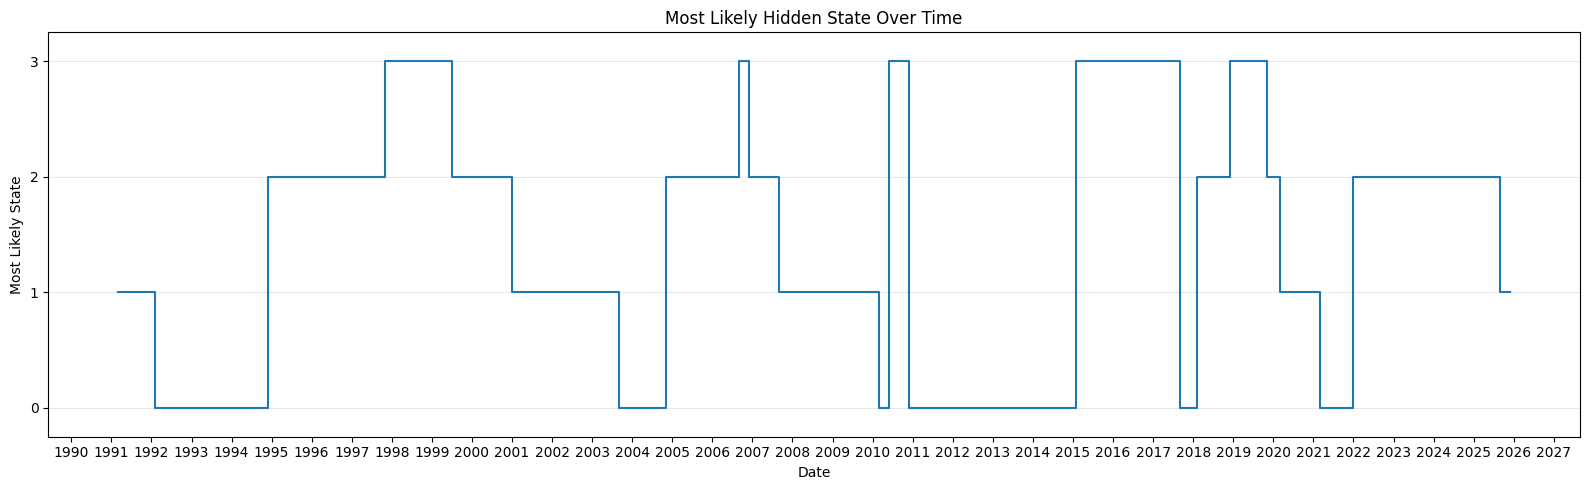

In [43]:
fig, ax = plt.subplots(figsize=(16, 5))

# Plot most likely state
ax.step(
    state_prob_df.index,
    state_prob_df["Most_Likely_State"],
    where="post"
)

# Y-axis formatting
ax.set_yticks([0, 1, 2, 3])
ax.set_ylim(-0.25, 3.25)
ax.set_ylabel("Most Likely State")

# X-axis formatting
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Date")

# Horizontal gridlines only
ax.grid(axis="y", alpha=0.3)

ax.set_title("Most Likely Hidden State Over Time")

plt.tight_layout()
plt.show()

In [44]:
# Load Real, Quarterly, Seasonally Adjusted GDP
df_gdp = pd.read_csv("gdp_quarterly_growth.csv")
df_gdp['Date'] = pd.to_datetime(df_gdp['Date'])
df_gdp.set_index('Date', inplace=True)
df_gdp = df_gdp.drop(index=["2026-01-01", "2026-04-01"])
df_gdp.tail()

,Real_GDP,GDP_YoY_Growth
Date,,
2024-10-01,23586.542,2.399788
2025-01-01,23548.210,2.019273
2025-04-01,23770.976,2.080467
2025-07-01,24026.834,2.335168
2025-10-01,24055.749,1.989300


In [45]:
# Load NBER Recession Indicator
df_recession = pd.read_csv("USREC.csv")
df_recession['observation_date'] = pd.to_datetime(df_recession['observation_date'])
df_recession.set_index('observation_date', inplace=True)
df_recession = df_recession.drop(index=["2026-01-01","2026-02-01","2026-03-01","2026-04-01","2026-05-01", "2026-06-01", "2026-07-01"])
df_recession.tail()

,USREC
observation_date,
2025-08-01,0
2025-09-01,0
2025-10-01,0
2025-11-01,0
2025-12-01,0


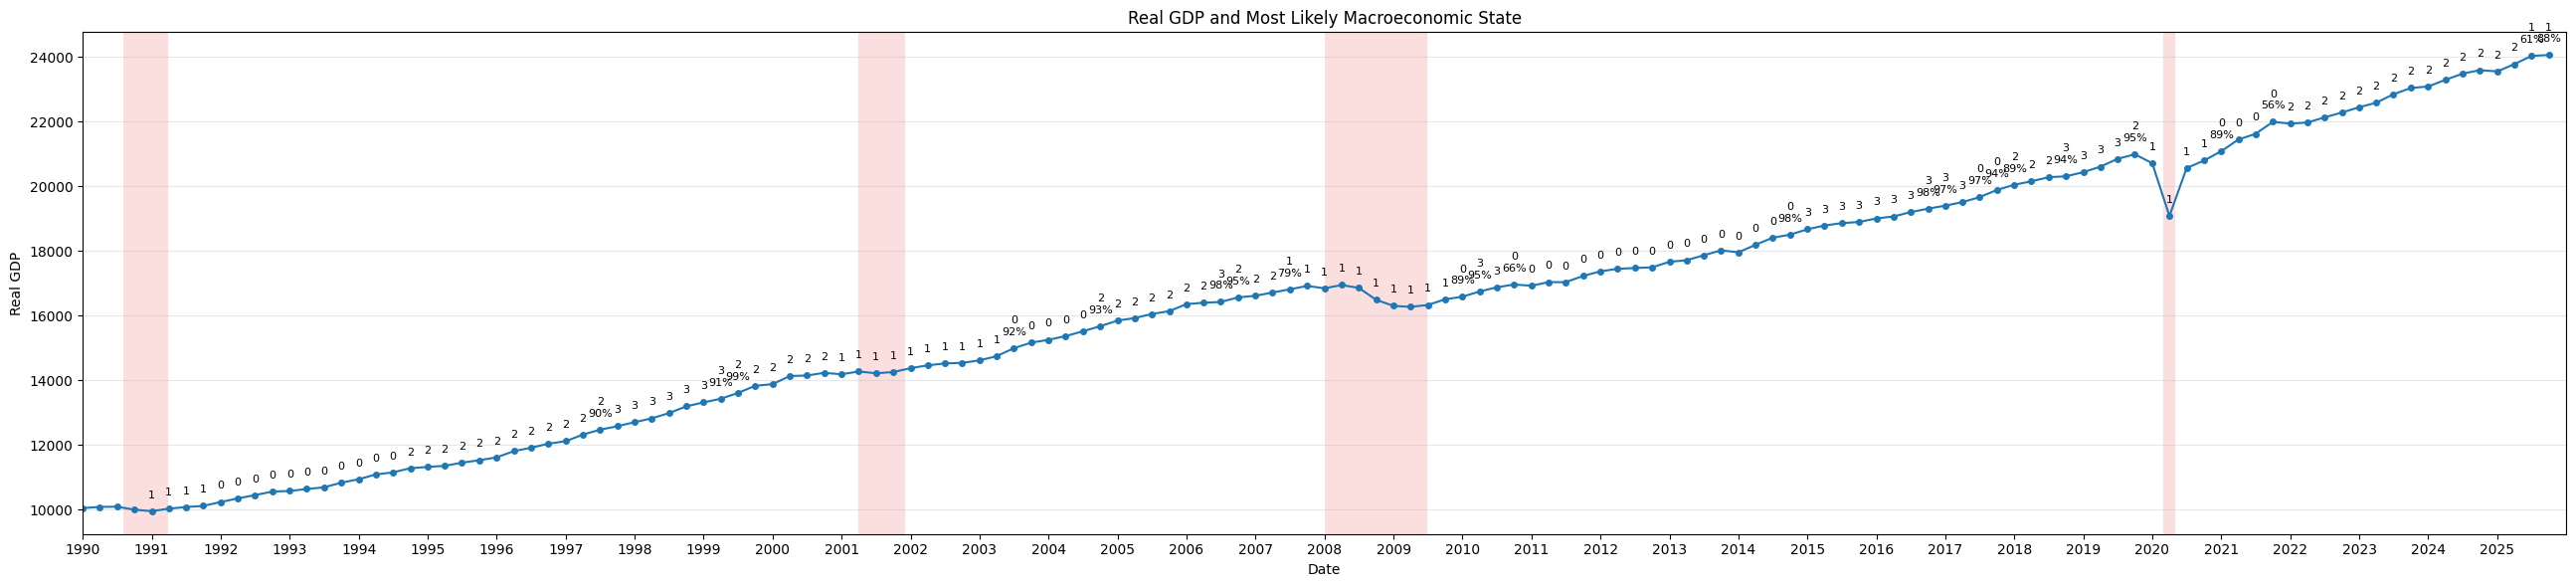

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Make sure indexes are datetime
df_gdp.index = pd.to_datetime(df_gdp.index)
state_prob_df.index = pd.to_datetime(state_prob_df.index)
df_recession.index = pd.to_datetime(df_recession.index)

# --------------------------------------------------
# Create GDP plotting dataframe
# --------------------------------------------------

gdp_plot_df = df_gdp[["Real_GDP"]].copy()

# Find last month of each GDP quarter
# Example: 1990-01-01 -> 1990-03-01
gdp_plot_df["Quarter_End_Month"] = (
    gdp_plot_df.index
    .to_period("Q")
    .asfreq("M", how="end")
    .to_timestamp()
)

# Get most likely state in the final month of each quarter
gdp_plot_df["Most_Likely_State"] = (
    state_prob_df["Most_Likely_State"]
    .reindex(gdp_plot_df["Quarter_End_Month"])
    .to_numpy()
)

gdp_plot_df["State_Probability"] = [
    state_prob_df.loc[date, f"P_State_{int(state)}"]
    if pd.notna(state) else np.nan
    for date, state in zip(
        gdp_plot_df["Quarter_End_Month"],
        gdp_plot_df["Most_Likely_State"]
    )
]

# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(26, 6))

# Real GDP
ax.plot(
    gdp_plot_df.index,
    gdp_plot_df["Real_GDP"],
    marker="o",
    markersize=4,
    label="Real GDP"
)

# --------------------------------------------------
# Recession shading
# --------------------------------------------------

recession = df_recession["USREC"].eq(1)

# Identify recession start and end months
recession_starts = df_recession.index[
    recession & ~recession.shift(1, fill_value=False)
]

recession_ends = df_recession.index[
    recession & ~recession.shift(-1, fill_value=False)
]

# Shade each recession
for start, end in zip(recession_starts, recession_ends):

    # Extend through the full final recession month
    end = end + pd.offsets.MonthEnd(1)

    ax.axvspan(
        start,
        end,
        color="lightcoral",
        alpha=0.25,
        linewidth=0
    )

# --------------------------------------------------
# State labels
# --------------------------------------------------

for date, row in gdp_plot_df.iterrows():

    if (
        pd.notna(row["Most_Likely_State"])
        and pd.notna(row["State_Probability"])
    ):

        state = int(row["Most_Likely_State"])
        probability = row["State_Probability"]

        # Only show probability when it is below 99%
        if probability < 0.99:
            label = f"{state}\n{probability:.0%}"
        else:
            label = f"{state}"

        ax.annotate(
            label,
            xy=(date, row["Real_GDP"]),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8
        )

# --------------------------------------------------
# Formatting
# --------------------------------------------------

ax.set_xlim(
    pd.Timestamp("1990-01-01"),
    pd.Timestamp("2025-12-31")
)

ax.xaxis.set_major_locator(
    mdates.YearLocator(1)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

ax.set_title(
    "Real GDP and Most Likely Macroeconomic State"
)

ax.set_xlabel("Date")
ax.set_ylabel("Real GDP")

# Horizontal gridlines only
ax.grid(
    axis="y",
    alpha=0.3
)

fig.savefig(
    "r_GDP_and_states.png",
    dpi=600,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

# Interpretation - 5 Latent States

In [54]:
best_results = None
best_log_likelihood = -np.inf

for seed in range(25):

    results = baum_welch(
        X,
        n_states=5,
        n_categories=3,
        persistence=0.80,
        max_iter=500,
        tol=1e-6,
        random_state=seed,
        verbose=False
    )

    if results["log_likelihood"] > best_log_likelihood:

        best_log_likelihood = (
            results["log_likelihood"]
        )

        best_results = results

In [55]:
best_results["log_likelihood"]

np.float64(-3718.8318598627793)

In [56]:
cutpoints[col] = (q1, q2)

In [57]:
cutoff_df = pd.DataFrame(
    {
        var: {
            "Low": f"<= {q1:.4f}",
            "Middle": f"> {q1:.4f} and <= {q2:.4f}",
            "High": f"> {q2:.4f}"
        }
        for var, (q1, q2) in cutpoints.items()
    }
).T

cutoff_df

,Low,Middle,High
Yield_Curve_Spread_MonthEnd,<= 0.4300,> 0.4300 and <= 1.4900,> 1.4900
CPI_YoY,<= 2.0208,> 2.0208 and <= 2.9415,> 2.9415
Industrial_Production_YoY,<= 0.9407,> 0.9407 and <= 3.2088,> 3.2088
Industrial_Production_MoM,<= -0.0668,> -0.0668 and <= 0.4033,> 0.4033
Housing_Starts_YoY,<= -2.3448,> -2.3448 and <= 8.7362,> 8.7362
Housing_Starts_MoM,<= -2.6279,> -2.6279 and <= 3.6485,> 3.6485
Real_PCE_YoY,<= 2.0099,> 2.0099 and <= 2.9060,> 2.9060
Unemployment_Rate_YoY_Change,<= -0.5000,> -0.5000 and <= 0.0000,> 0.0000
Unemployment_Rate_MoM_Change,<= -0.1000,> -0.1000 and <= 0.0000,> 0.0000
Log_VIX_MonthAvg,<= 2.7228,> 2.7228 and <= 3.0137,> 3.0137


In [58]:
pi_hat = results["pi"]
A_hat = results["A"].round(5)
B_hat = results["B"]
gamma = results["gamma"]

In [59]:
transition_df = pd.DataFrame(
    A_hat,
    index=["State_0", "State_1", "State_2", "State_3", "State_4"],
    columns=["State_0", "State_1", "State_2", "State_3", "State_4"]
)

transition_df

,State_0,State_1,State_2,State_3,State_4
State_0,0.95746,0.02205,0.00000,0.00000,0.02049
State_1,0.00000,0.96900,0.00000,0.00000,0.03100
State_2,0.00000,0.08022,0.91978,0.00000,0.00000
State_3,0.00000,0.00000,0.04140,0.95860,0.00000
State_4,0.01211,0.00573,0.00000,0.01199,0.97017


In [60]:
emission_tables = {}

for v, var in enumerate(observed_vars):

    emission_tables[var] = pd.DataFrame(
        B_hat[v],
        index=[
            "State_0",
            "State_1",
            "State_2",
            "State_3",
            "State_4"
        ],
        columns=[
            "Low",
            "Middle",
            "High"
        ]
    )

    print(f"\n{var}")
    print(emission_tables[var].round(3))


Yield_Curve_Spread_MonthEnd
           Low  Middle   High
State_0  0.863   0.021  0.116
State_1  0.282   0.345  0.373
State_2  1.000   0.000  0.000
State_3  0.177   0.759  0.064
State_4  0.190   0.320  0.490

CPI_YoY
           Low  Middle   High
State_0  0.495   0.293  0.212
State_1  0.291   0.258  0.451
State_2  0.481   0.519  0.000
State_3  0.626   0.374  0.000
State_4  0.217   0.363  0.420

Industrial_Production_YoY
           Low  Middle   High
State_0  0.000   0.064  0.936
State_1  0.774   0.210  0.016
State_2  0.481   0.519  0.000
State_3  0.538   0.325  0.137
State_4  0.000   0.480  0.520

Industrial_Production_MoM
           Low  Middle   High
State_0  0.209   0.348  0.444
State_1  0.480   0.246  0.274
State_2  0.439   0.400  0.160
State_3  0.482   0.270  0.249
State_4  0.193   0.410  0.397

Housing_Starts_YoY
           Low  Middle   High
State_0  0.309   0.458  0.233
State_1  0.526   0.316  0.158
State_2  0.599   0.241  0.160
State_3  0.218   0.415  0.367
State_4  0.187   0

In [61]:
emission_argmax_df = pd.DataFrame({
    var: table.idxmax(axis=1)
    for var, table in emission_tables.items()
}).T

emission_argmax_df.columns = [
    "State_0",
    "State_1",
    "State_2",
    "State_3",
    "State_4"
]

emission_argmax_df

,State_0,State_1,State_2,State_3,State_4
Yield_Curve_Spread_MonthEnd,Low,High,Low,Middle,High
CPI_YoY,Low,High,Middle,Low,High
Industrial_Production_YoY,High,Low,Middle,Low,High
Industrial_Production_MoM,High,Low,Low,Low,Middle
Housing_Starts_YoY,Middle,Low,Low,Middle,High
Housing_Starts_MoM,Middle,Low,Middle,Low,High
Real_PCE_YoY,High,Low,Middle,Middle,High
Unemployment_Rate_YoY_Change,Middle,High,Middle,Low,Low
Unemployment_Rate_MoM_Change,Low,High,Low,Low,Low
Log_VIX_MonthAvg,High,High,Low,Low,Low


In [62]:
state_prob_df = df_discrete.copy()

for s in range(5):
    state_prob_df[
        f"P_State_{s}"
    ] = gamma[:, s].round(7)

state_prob_df["Most_Likely_State"] = (
    gamma.argmax(axis=1)
)

In [63]:
state_prob_df[
    [
        "P_State_0",
        "P_State_1",
        "P_State_2",
        "P_State_3",
        "P_State_4",
        "Most_Likely_State"
    ]
].tail(20)

,P_State_0,P_State_1,P_State_2,P_State_3,P_State_4,Most_Likely_State
Date,,,,,,
2024-05-01,0.0,1.000000,0.0,0.0,0.000000,1
2024-06-01,0.0,1.000000,0.0,0.0,0.000000,1
2024-07-01,0.0,1.000000,0.0,0.0,0.000000,1
2024-08-01,0.0,1.000000,0.0,0.0,0.000000,1
2024-09-01,0.0,1.000000,0.0,0.0,0.000000,1
2024-10-01,0.0,1.000000,0.0,0.0,0.000000,1
2024-11-01,0.0,1.000000,0.0,0.0,0.000000,1
2024-12-01,0.0,1.000000,0.0,0.0,0.000000,1
2025-01-01,0.0,1.000000,0.0,0.0,0.000000,1


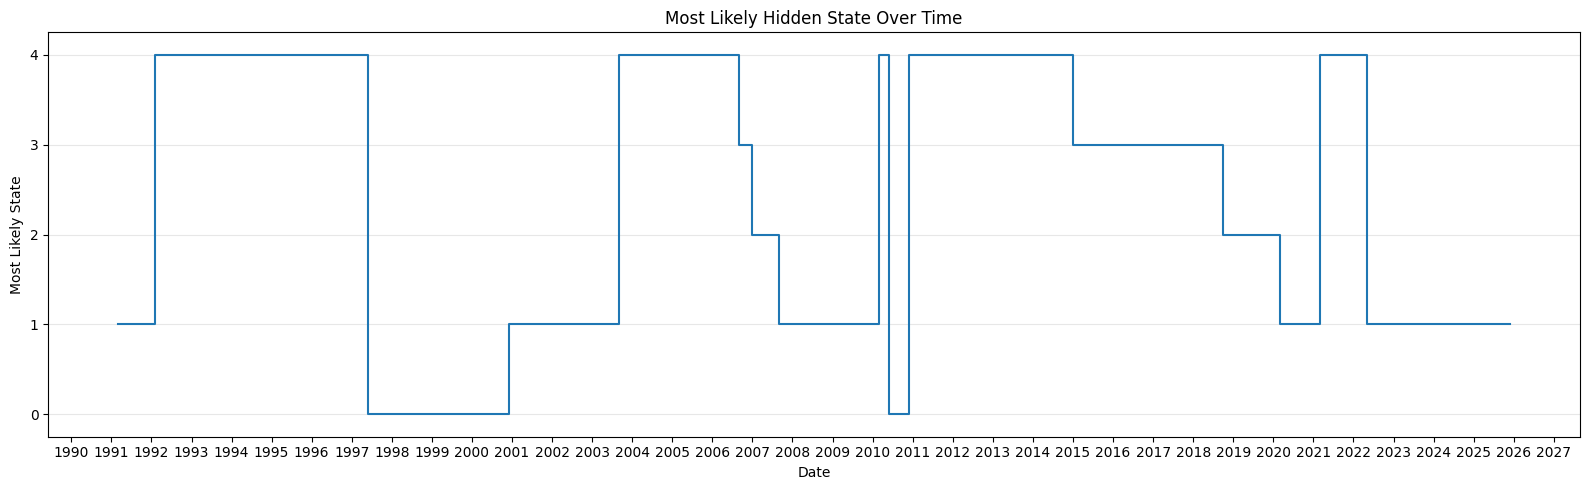

In [64]:
fig, ax = plt.subplots(figsize=(16, 5))

# Plot most likely state
ax.step(
    state_prob_df.index,
    state_prob_df["Most_Likely_State"],
    where="post"
)

# Y-axis formatting
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_ylim(-0.25, 4.25)
ax.set_ylabel("Most Likely State")

# X-axis formatting
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Date")

# Horizontal gridlines only
ax.grid(axis="y", alpha=0.3)

ax.set_title("Most Likely Hidden State Over Time")

plt.tight_layout()
plt.show()

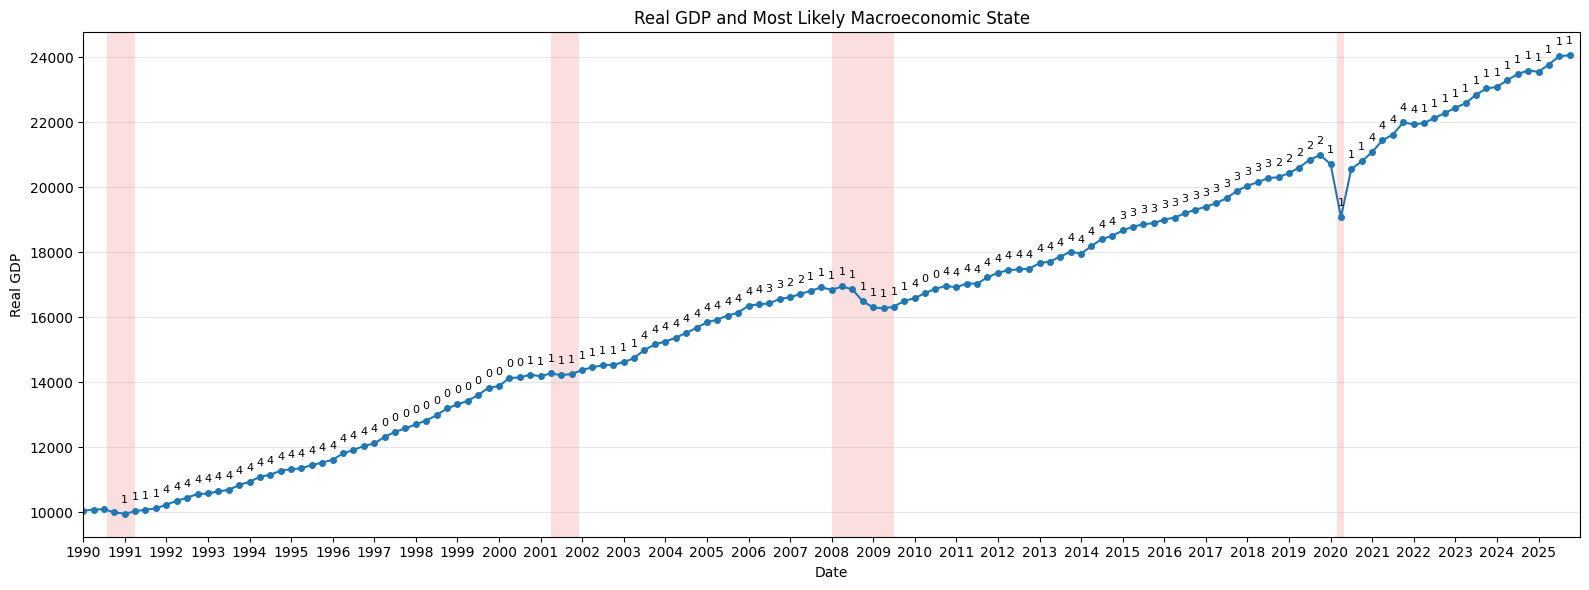

In [66]:
# Make sure indexes are datetime
df_gdp.index = pd.to_datetime(df_gdp.index)
state_prob_df.index = pd.to_datetime(state_prob_df.index)
df_recession.index = pd.to_datetime(df_recession.index)

# --------------------------------------------------
# Create GDP plotting dataframe
# --------------------------------------------------

gdp_plot_df = df_gdp[["Real_GDP"]].copy()

# Find last month of each GDP quarter
# Example: 1990-01-01 -> 1990-03-01
gdp_plot_df["Quarter_End_Month"] = (
    gdp_plot_df.index
    .to_period("Q")
    .asfreq("M", how="end")
    .to_timestamp()
)

# Get most likely state in the final month of each quarter
gdp_plot_df["Most_Likely_State"] = (
    state_prob_df["Most_Likely_State"]
    .reindex(gdp_plot_df["Quarter_End_Month"])
    .to_numpy()
)

# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 6))

# Real GDP
ax.plot(
    gdp_plot_df.index,
    gdp_plot_df["Real_GDP"],
    marker="o",
    markersize=4,
    label="Real GDP"
)

# --------------------------------------------------
# Recession shading
# --------------------------------------------------

recession = df_recession["USREC"].eq(1)

# Identify recession start and end months
recession_starts = df_recession.index[
    recession & ~recession.shift(1, fill_value=False)
]

recession_ends = df_recession.index[
    recession & ~recession.shift(-1, fill_value=False)
]

# Shade each recession
for start, end in zip(recession_starts, recession_ends):

    # Extend through the full final recession month
    end = end + pd.offsets.MonthEnd(1)

    ax.axvspan(
        start,
        end,
        color="lightcoral",
        alpha=0.25,
        linewidth=0
    )

# --------------------------------------------------
# State labels
# --------------------------------------------------

for date, row in gdp_plot_df.iterrows():

    if pd.notna(row["Most_Likely_State"]):

        ax.annotate(
            f'{int(row["Most_Likely_State"])}',
            xy=(date, row["Real_GDP"]),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

# --------------------------------------------------
# Formatting
# --------------------------------------------------

ax.set_xlim(
    pd.Timestamp("1990-01-01"),
    pd.Timestamp("2025-12-31")
)

ax.xaxis.set_major_locator(
    mdates.YearLocator(1)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

ax.set_title(
    "Real GDP and Most Likely Macroeconomic State"
)

ax.set_xlabel("Date")
ax.set_ylabel("Real GDP")

# Horizontal gridlines only
ax.grid(
    axis="y",
    alpha=0.3
)

fig.savefig(
    "r_GDP_and_states_5_states.png",
    dpi=600,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()